# Part 5


Imports

In [1]:
import os
import re
import json
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.calibration import CalibratedClassifierCV

from transformers import AutoTokenizer, AutoModelForSequenceClassification

Settings

In [2]:
SEED = 42
DATA_PATH = r"dataset/jigsaw-unintended-bias-train.csv"
VALIDATION_PATH = r"dataset/validation.csv"

# keep same split sizes as earlier notebooks
TRAIN_SIZE = 10_000
EVAL_SIZE = 2_000
MAX_LEN = 128

# choose the best mitigated model from Part 4
BEST_MODEL_DIR = "saved_models/part4_oversample_model"

CALIBRATOR_PATH = "saved_models/part5_isotonic_calibrator.pkl"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("Using model:", BEST_MODEL_DIR)

Device: cpu
Using model: saved_models/part4_oversample_model


In [3]:
df = pd.read_csv(
    DATA_PATH,
    usecols=["comment_text", "toxic", "black", "white"]
)

df = df.dropna(subset=["comment_text", "toxic"]).copy()
df["label"] = (df["toxic"] >= 0.5).astype(int)

sample_total = TRAIN_SIZE + EVAL_SIZE

sampled_df, _ = train_test_split(
    df,
    train_size=sample_total,
    stratify=df["label"],
    random_state=SEED
)

train_df, eval_df = train_test_split(
    sampled_df,
    train_size=TRAIN_SIZE,
    test_size=EVAL_SIZE,
    stratify=sampled_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
eval_df = eval_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Eval shape :", eval_df.shape)

Train shape: (10000, 5)
Eval shape : (2000, 5)


In [4]:
val_df = pd.read_csv(
    VALIDATION_PATH,
    usecols=["comment_text", "toxic"]
)

val_df = val_df.dropna(subset=["comment_text", "toxic"]).copy()
val_df["label"] = (val_df["toxic"] >= 0.5).astype(int)

print("Validation shape:", val_df.shape)
val_df.head()

Validation shape: (8000, 3)


,comment_text,toxic,label
0,Este usuario ni siquiera llega al rango de ...,0,0
1,Il testo di questa voce pare esser scopiazzato...,0,0
2,Vale. Sólo expongo mi pasado. Todo tiempo pasa...,1,1
3,Bu maddenin alt başlığı olarak uluslararası i...,0,0
4,Belçika nın şehirlerinin yanında ilçe ve belde...,0,0


Load tokenizer and best mitigated model

In [5]:
tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(BEST_MODEL_DIR).to(DEVICE)
model.eval()

print("Model loaded.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded.


Raw probability helper

In [6]:
def predict_raw_probs(texts, batch_size=16):
    probs_all = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        enc = tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

        probs_all.extend(probs)

    return np.array(probs_all)

Fit isotonic calibrator with CalibratedClassifierCV

In [8]:
from sklearn.isotonic import IsotonicRegression

raw_val_probs = predict_raw_probs(val_df["comment_text"].tolist())
y_cal = val_df["label"].values

isotonic_calibrator = IsotonicRegression(
    y_min=0.0,
    y_max=1.0,
    increasing=True,
    out_of_bounds="clip"
)

isotonic_calibrator.fit(raw_val_probs, y_cal)

joblib.dump(isotonic_calibrator, CALIBRATOR_PATH)
print("Saved calibrator to:", CALIBRATOR_PATH)

Saved calibrator to: saved_models/part5_isotonic_calibrator.pkl


In [9]:
pipeline_code = r'''
import re
import joblib
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

BLOCKLIST = {
    "direct_threat": [
        re.compile(r"\bi(?:'ll| will| am going to| gonna)\s+(kill|hurt|shoot|stab|murder)\s+you\b", re.IGNORECASE),
        re.compile(r"\byou(?:'re| are)\s+going\s+to\s+die\b", re.IGNORECASE),
        re.compile(r"\bsomeone\s+should\s+(kill|shoot|hurt)\s+you\b", re.IGNORECASE),
        re.compile(r"\bi(?:'ll| will)\s+find\s+where\s+you\s+live\b", re.IGNORECASE),
        re.compile(r"\bi(?:'ll| will)\s+come\s+for\s+you\b", re.IGNORECASE),
    ],
    "self_harm_directed": [
        re.compile(r"\bgo\s+kill\s+yourself\b", re.IGNORECASE),
        re.compile(r"\byou\s+should\s+kill\s+yourself\b", re.IGNORECASE),
        re.compile(r"\bnobody\s+would\s+miss\s+you\s+if\s+you\s+died\b", re.IGNORECASE),
        re.compile(r"\bdo\s+everyone\s+a\s+favor\s+and\s+disappear\b", re.IGNORECASE),
    ],
    "doxxing_stalking": [
        re.compile(r"\bi\s+know\s+where\s+you\s+live\b", re.IGNORECASE),
        re.compile(r"\bi(?:'ll| will)\s+post\s+your\s+address\b", re.IGNORECASE),
        re.compile(r"\bi\s+found\s+your\s+real\s+name\b", re.IGNORECASE),
        re.compile(r"\beveryone\s+will\s+know\s+who\s+you\s+really\s+are\b", re.IGNORECASE),
    ],
    "dehumanization": [
        re.compile(r"\b\w+\s+are\s+not\s+(?:human|people|persons)\b", re.IGNORECASE),
        re.compile(r"\b\w+\s+are\s+animals\b", re.IGNORECASE),
        re.compile(r"\b\w+\s+should\s+be\s+exterminated\b", re.IGNORECASE),
        re.compile(r"\b\w+\s+are\s+a\s+disease\b", re.IGNORECASE),
    ],
    "coordinated_harassment": [
        re.compile(r"\beveryone\s+report\s+\w+\b", re.IGNORECASE),
        re.compile(r"\blet(?:'s|\s+us)\s+all\s+go\s+after\b", re.IGNORECASE),
        re.compile(r"\braid\s+their\s+profile\b", re.IGNORECASE),
        re.compile(r"\bmass\s+report\b(?=.*account)", re.IGNORECASE),
    ],
}

def input_filter(text: str):
    for category, patterns in BLOCKLIST.items():
        for pattern in patterns:
            if pattern.search(text):
                return {
                    "decision": "block",
                    "layer": "input_filter",
                    "category": category,
                    "confidence": 1.0
                }
    return None


class ModerationPipeline:
    def __init__(
        self,
        model_dir="saved_models/part4_oversample_model",
        calibrator_path="saved_models/part5_isotonic_calibrator.pkl",
        threshold_allow=0.4,
        threshold_block=0.6,
        max_len=128
    ):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model_dir = model_dir
        self.calibrator_path = calibrator_path
        self.threshold_allow = threshold_allow
        self.threshold_block = threshold_block
        self.max_len = max_len

        self.tokenizer = AutoTokenizer.from_pretrained(model_dir)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(self.device)
        self.model.eval()

        self.calibrator = joblib.load(calibrator_path)

    def predict_raw_proba(self, text: str) -> float:
        enc = self.tokenizer(
            text,
            truncation=True,
            padding=True,
            max_length=self.max_len,
            return_tensors="pt"
        ).to(self.device)

        with torch.no_grad():
            logits = self.model(**enc).logits
            prob = torch.softmax(logits, dim=1)[:, 1].item()

        return float(prob)

    def predict_calibrated_proba(self, text: str) -> float:
        raw_prob = self.predict_raw_proba(text)
        calibrated_prob = float(self.calibrator.predict([raw_prob])[0])
        return calibrated_prob

    def predict(self, text: str):
        layer1 = input_filter(text)
        if layer1 is not None:
            return layer1

        calibrated_prob = self.predict_calibrated_proba(text)

        if calibrated_prob >= self.threshold_block:
            return {
                "decision": "block",
                "layer": "model",
                "confidence": calibrated_prob
            }
        elif calibrated_prob <= self.threshold_allow:
            return {
                "decision": "allow",
                "layer": "model",
                "confidence": calibrated_prob
            }
        else:
            return {
                "decision": "review",
                "layer": "model",
                "confidence": calibrated_prob
            }
'''

with open("pipeline.py", "w", encoding="utf-8") as f:
    f.write(pipeline_code)

print("pipeline.py written successfully.")

pipeline.py written successfully.


Load the pipeline

In [10]:
from pipeline import ModerationPipeline, input_filter

pipeline = ModerationPipeline(
    model_dir=BEST_MODEL_DIR,
    calibrator_path=CALIBRATOR_PATH,
    threshold_allow=0.4,
    threshold_block=0.6
)

print("Pipeline loaded.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Pipeline loaded.


Run the pipeline on 1,000 evaluation

In [11]:
demo_df = eval_df.sample(n=1000, random_state=SEED).reset_index(drop=True)

results = []
for _, row in demo_df.iterrows():
    out = pipeline.predict(row["comment_text"])
    results.append({
        "comment_text": row["comment_text"],
        "label": row["label"],
        **out
    })

results_df = pd.DataFrame(results)
results_df.head()

,comment_text,label,decision,layer,confidence
0,Thank God the police were notified and had tim...,0,allow,model,0.053476
1,Not interested enough to google it for yoursel...,0,allow,model,0.000000
2,"""Public Education"" has not evolved logically. ...",0,allow,model,0.000000
3,It is customary to a avoid insulting those who...,0,allow,model,0.000000
4,Peter; there are agricultural jobs where Ameri...,0,allow,model,0.053476


Layer distribution + category counts

In [14]:
# Ensure column exists
if "category" not in results_df.columns:
    results_df["category"] = None

layer_counts = results_df["layer"].value_counts()
decision_counts = results_df["decision"].value_counts()
category_counts = results_df["category"].fillna("not_input_filter").value_counts()

print("Layer counts:")
print(layer_counts)

print("\nDecision counts:")
print(decision_counts)

print("\nInput-filter category counts:")
print(category_counts)

Layer counts:
layer
model    1000
Name: count, dtype: int64

Decision counts:
decision
allow     893
review     87
block      20
Name: count, dtype: int64

Input-filter category counts:
category
not_input_filter    1000
Name: count, dtype: int64


Plot layer distribution

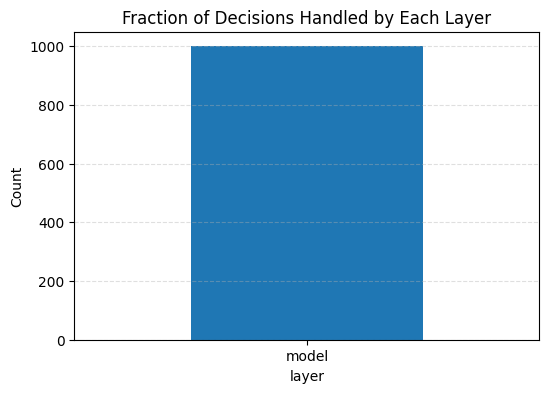

In [15]:
plt.figure(figsize=(6, 4))
layer_counts.plot(kind="bar")
plt.title("Fraction of Decisions Handled by Each Layer")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

Auto-action metrics

In [16]:
auto_df = results_df[results_df["decision"].isin(["block", "allow"])].copy()
auto_df["pred_binary"] = (auto_df["decision"] == "block").astype(int)

auto_f1 = f1_score(auto_df["label"], auto_df["pred_binary"], average="macro")
auto_precision = precision_score(auto_df["label"], auto_df["pred_binary"], zero_division=0)
auto_recall = recall_score(auto_df["label"], auto_df["pred_binary"], zero_division=0)

print("Auto-action subset size:", len(auto_df))
print("F1 Macro :", auto_f1)
print("Precision:", auto_precision)
print("Recall   :", auto_recall)

Auto-action subset size: 913
F1 Macro : 0.7656691134952005
Precision: 0.75
Recall   : 0.42857142857142855


Review queue breakdown

In [17]:
review_df = results_df[results_df["decision"] == "review"].copy()

review_breakdown_counts = review_df["label"].value_counts()
review_breakdown_props = review_df["label"].value_counts(normalize=True)

print("Review queue size:", len(review_df))
print("\nReview queue counts:")
print(review_breakdown_counts)
print("\nReview queue proportions:")
print(review_breakdown_props)

Review queue size: 87

Review queue counts:
label
0    48
1    39
Name: count, dtype: int64

Review queue proportions:
label
0    0.551724
1    0.448276
Name: proportion, dtype: float64


Sensitivity analysis for alternative uncertainty bands

In [18]:
bands = [
    (0.4, 0.6),
    (0.45, 0.55),
    (0.3, 0.7),
]

sensitivity_rows = []

for allow_th, block_th in bands:
    temp_pipeline = ModerationPipeline(
        model_dir=BEST_MODEL_DIR,
        calibrator_path=CALIBRATOR_PATH,
        threshold_allow=allow_th,
        threshold_block=block_th
    )

    temp_results = []
    for _, row in demo_df.iterrows():
        out = temp_pipeline.predict(row["comment_text"])
        temp_results.append({
            "label": row["label"],
            **out
        })

    temp_df = pd.DataFrame(temp_results)

    auto_subset = temp_df[temp_df["decision"].isin(["block", "allow"])].copy()
    auto_subset["pred_binary"] = (auto_subset["decision"] == "block").astype(int)

    review_volume = (temp_df["decision"] == "review").mean()

    sensitivity_rows.append({
        "Band": f"{allow_th}-{block_th}",
        "ReviewVolume": review_volume,
        "AutoActionF1": f1_score(auto_subset["label"], auto_subset["pred_binary"], average="macro") if len(auto_subset) else np.nan,
        "AutoActionPrecision": precision_score(auto_subset["label"], auto_subset["pred_binary"], zero_division=0) if len(auto_subset) else np.nan,
        "AutoActionRecall": recall_score(auto_subset["label"], auto_subset["pred_binary"], zero_division=0) if len(auto_subset) else np.nan,
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,Band,ReviewVolume,AutoActionF1,AutoActionPrecision,AutoActionRecall
0,0.4-0.6,0.087,0.765669,0.750000,0.428571
1,0.45-0.55,0.002,0.686469,0.740741,0.277778
2,0.3-0.7,0.169,0.821136,0.750000,0.576923


Save Part 5 outputs

In [19]:
results_df.to_csv("saved_models/part5_pipeline_results.csv", index=False)
sensitivity_df.to_csv("saved_models/part5_sensitivity_results.csv", index=False)

print("Saved:")
print(" - saved_models/part5_pipeline_results.csv")
print(" - saved_models/part5_sensitivity_results.csv")
print(" - pipeline.py")
print(" -", CALIBRATOR_PATH)

Saved:
 - saved_models/part5_pipeline_results.csv
 - saved_models/part5_sensitivity_results.csv
 - pipeline.py
 - saved_models/part5_isotonic_calibrator.pkl
